# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Szan-12345/FLYRANK-MACHINE-LEARNING/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Decision this supports: Each review cycle, a content team has capacity to manually check only a fraction of a client's inventory. This project decides which content items get that limited attention first.

Unit of analysis: One content item's search performance for one client over a 15-day window (client_hash_id + content_hash_id, aggregated from daily rows in fact_content_daily_performance) — not a single day, and not the page in the abstract. Scored against 120,513–331,437+ such content-item windows per month-slice, drawn from a 78.8-million-row production table.

Output: A ranked action queue — not a bare yes/no. Each flagged item carries an action_score (the primary, transparent rule-based signal), a model_score (a secondary confidence check), and reason codes (IMPR_DROP, CLICK_DROP, POSITION_SLIP, ACTIVITY_DROP) explaining why it was flagged.

Action a human takes: A content strategist opens a flagged item, reads its reason codes, and picks a specific move — rewrite, expand a thin section, update a stale fact, fix a technical issue, or leave it alone. The system doesn't choose the fix; it chooses where to look first.

Cost of a wrong call:

False positive — a flagged item that wasn't really worth it — burns a reviewer's fixed, limited hours on the wrong page.
False negative — a real decline that never gets flagged — keeps eroding silently and compounds the longer it's missed.

Both costs are about the ordering of the queue, not a single accuracy number — which is why the project is evaluated on precision-at-K / PR-AUC rather than raw accuracy, and why "scoring," not plain classification, is the right frame.

Why data/ML helps instead of a fixed rule: Two things ruled out an if-statement early. First, the obvious heuristic — "old content is what's declining" — doesn't hold: median content age is actually similar or lower for declining items than for stable or growing ones in the initial exploration, so age alone is a false signal. Second, single-threshold rules create both blind spots and ties: items just under a cutoff get ignored outright, and large blocks of items sharing one value can't be told apart by that value alone. The production rule-based baseline itself surfaced a related failure once real data was used — it couldn't tell a 52-impression item from a 3,772-impression item, scoring both about the same ("scale blindness") — which is direct evidence that a single hand-tuned formula misses a signal a model picks up by combining several features at once.

In [1]:
# This cell is for CODE (numbers, a query, a check).
%pip -q install duckdb huggingface_hub

import os, getpass, json
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':       f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':       f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample': f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':    f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

# Rule constants — unchanged from Week 4, reused everywhere in this project
WINDOW_DAYS        = 15
MIN_PREV_IMPR      = 50
IMPR_DROP_THRESH   = 0.20
CLICK_DROP_THRESH  = 0.20
POS_SLIP_THRESH    = 1.0
ACTIVITY_DROP_FRAC = 0.25
W_IMPR, W_CLICK, W_POS, W_ACTIVITY = 0.40, 0.25, 0.20, 0.15
SEED = 42

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

print('connected — tables registered, rule constants set, SEED =', SEED)


connected — tables registered, rule constants set, SEED = 42


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



**Release:** FlyRank ML Internship dataset (`FlyRank/internship-warehouse` on Hugging Face) — the same warehouse used throughout the project, queried directly via DuckDB rather than downloaded in bulk.

### Tables Touched and Role
| Table | Size | Role |
| :--- | :--- | :--- |
| `fact_content_daily_performance` | 78,835,655 rows | **Primary source** — every feature and every label in this project is derived from it. |
| `dim_clients` | 104 rows | **Reference only** — used to check per-client data-history spread (see Limits, below), never joined into the feature or label pipeline. |
| `dim_content` | 519,606 rows | **Reference only** — not joined into scoring; content items are addressed by hashed ID. |
| `fact_content_daily_performance_sample` | 11,694,072 rows | **Not used.** A separate, sealed sample (June 2026) — deliberately left untouched as a potential future holdout, not queried for any result in this paper. |
| `fact_content_query_90d` | 2,414,248 rows | **Excluded entirely.** Its 90-day trailing window isn't confirmed aligned to any specific decision date, so joining it in risks a window-alignment leak. Left out at the table level, not filtered after the fact. |

---

### Date Windows
Two different window designs were used for two different purposes:
* **Early Exploration (Data-Contract Check):** Used calendar-month March 2026, split at the midpoint into a 15-day feature window and a 16-day outcome window. That asymmetry (15 vs. 16 days) is a small, disclosed limitation of that specific check (see Limitations) and is not the design the actual pipeline runs on.
* **Scoring Pipeline:** The baseline, model, and everything downstream instead anchor to `decision_day` (the most recent date present in the release) and compare two equal, adjacent 15-day windows ending there: a "prior" window and a "last" window. Both windows are fully in the past relative to `decision_day` by construction, so there is no future-outcome leakage to guard against in this design; the leakage risk here is cross-client (see Methodology), not cross-time.

---

### Scope After Filtering
* Items with fewer than 50 impressions in the prior window are dropped before scoring—a reliability floor (`MIN_PREV_IMPR = 50`), not a judgment call applied after the fact.
* This leaves **99,893 content items scored**, of which **78,630** carry at least one reason-code flag and make up the working review queue.
* The stricter model target (`high_confidence_decline`) requires prior-window impressions $\ge 250$ — five times the scoring floor — on top of a rule flag.

---

### What Was Excluded, and Why (Public-Safe)
* `fact_content_query_90d`: Window-alignment risk, excluded at the table level.
* `client_hash_id` / `content_hash_id`: Pseudonymous identifiers, used only to join and group; never used as a model feature.
* `report_date`: Defines the window boundary only, not a model input.
* `gsc_data_available`: A filter flag, not a feature.
* **The outcome-window impression total:** Never included as a feature. Including it on purpose, once, as a check, pushed AUC from an honest 0.590 to a leaky 1.000 — confirming it's pure label leakage if left in (see Methodology).

*Note: No client names, URLs, or query text appear anywhere in this project. The warehouse is pre-hashed at the source, and every notebook confirms no ID or free-text field survives into `work/outputs/`.*

---

### Data Limits (Disclosed, Not Corrected For)
* **Non-uniform client history:** `dim_clients` shows GSC start dates ranging from January 2025 to June 2026, meaning "the prior window" isn't equally deep in history for every client. Rows before a client's own data-start are zero-filled rather than representing verified zero engagement, and this project does not distinguish the two.
* **Search Console signal availability:** Only 36.7% of rows in the exploratory March slice had `gsc_data_available = TRUE`. A meaningful share of rows carry no usable Search Console signal, capping how much of the warehouse any single window's numbers actually speak for.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Verify the row counts cited in the Data table above, straight from the warehouse —
# these numbers should match what's written in the markdown cell above exactly.
for name in ['fact_daily', 'dim_clients', 'dim_content', 'fact_daily_sample', 'fact_query_90d']:
    n = con.sql(f"SELECT COUNT(*) AS n FROM {TABLES[name]}").df()['n'][0]
    print(f"{name:20s} {n:>15,} rows")

# Rebuild the scored population (Week-4 windowing logic) — two adjacent 15-day windows
# anchored to decision_day, the most recent date present in the release.
windowed = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS decision_day FROM {TABLES['fact_daily']}
    ),
    per_item AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,
            SUM(CASE WHEN f.report_date >  b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     THEN f.gsc_impressions ELSE 0 END)                              AS imp_last,
            SUM(CASE WHEN f.report_date <= b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     THEN f.gsc_impressions ELSE 0 END)                              AS imp_prev,
            SUM(CASE WHEN f.report_date >  b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     THEN f.gsc_clicks ELSE 0 END)                                   AS clk_last,
            SUM(CASE WHEN f.report_date <= b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     THEN f.gsc_clicks ELSE 0 END)                                   AS clk_prev,
            AVG(CASE WHEN f.report_date >  b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     THEN f.gsc_avg_position END)                                    AS pos_last,
            AVG(CASE WHEN f.report_date <= b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     THEN f.gsc_avg_position END)                                    AS pos_prev,
            COUNT(DISTINCT CASE WHEN f.report_date >  b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     AND f.gsc_impressions > 0 THEN f.report_date END)               AS active_days_last,
            COUNT(DISTINCT CASE WHEN f.report_date <= b.decision_day - INTERVAL ({WINDOW_DAYS}) DAY
                     AND f.gsc_impressions > 0 THEN f.report_date END)               AS active_days_prev,
            MAX(b.decision_day)                                                      AS decision_day
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.decision_day - INTERVAL ({2*WINDOW_DAYS}) DAY
          AND f.gsc_data_available IS TRUE
        GROUP BY 1, 2
    )
    SELECT * FROM per_item
    WHERE imp_prev >= {MIN_PREV_IMPR}
""").df()

d = windowed.copy()
d['pct_impr_change']  = (d['imp_last'] - d['imp_prev']) / d['imp_prev']
d['pct_click_change'] = np.where(d['clk_prev'] > 0, (d['clk_last'] - d['clk_prev']) / d['clk_prev'], np.nan)
d['pos_change']       = d['pos_last'] - d['pos_prev']
d['activity_change']  = (d['active_days_prev'] - d['active_days_last']) / d['active_days_prev'].clip(lower=1)

d['impr_drop_score']     = (-d['pct_impr_change']).clip(lower=0, upper=1)
d['click_drop_score']    = (-d['pct_click_change']).clip(lower=0, upper=1).fillna(0)
d['pos_slip_score']      = (d['pos_change'] / 5.0).clip(lower=0, upper=1)
d['activity_drop_score'] = d['activity_change'].clip(lower=0, upper=1)

def reasons(row):
    fired = []
    if row['pct_impr_change'] <= -IMPR_DROP_THRESH: fired.append('IMPR_DROP')
    if pd.notna(row['pct_click_change']) and row['pct_click_change'] <= -CLICK_DROP_THRESH: fired.append('CLICK_DROP')
    if row['pos_change'] >= POS_SLIP_THRESH: fired.append('POSITION_SLIP')
    if row['activity_change'] >= ACTIVITY_DROP_FRAC: fired.append('ACTIVITY_DROP')
    return fired

d['reason_codes']    = d.apply(reasons, axis=1)
d['n_reasons']        = d['reason_codes'].apply(len)
d['reason_codes_str'] = d['reason_codes'].apply(lambda r: '|'.join(r) if r else 'NONE')
d['action_score'] = (
    W_IMPR*d['impr_drop_score'] + W_CLICK*d['click_drop_score'] +
    W_POS*d['pos_slip_score'] + W_ACTIVITY*d['activity_drop_score']
).round(4)

n_eligible_clients = d['client_hash_id'].nunique()
print(f"\n{len(d):,} content items scored | {(d['n_reasons']>0).sum():,} flagged by the rule")
print(f"Eligible clients (cleared the reliability floor): {n_eligible_clients}")
print("--> use this printed number, not a remembered one, anywhere the paper cites a client count.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily                78,835,655 rows
dim_clients                      104 rows
dim_content                  519,606 rows
fact_daily_sample         11,694,072 rows
fact_query_90d             2,414,248 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


99,893 content items scored | 78,630 flagged by the rule
Eligible clients (cleared the reliability floor): 46
--> use this printed number, not a remembered one, anywhere the paper cites a client count.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Core assumption: two adjacent, equal-length windows (prior 15 days vs. last 15 days, both ending at decision_day) are a fair basis for "getting worse" — but only once volume is high enough that a percentage swing means something. Below that floor, noise looks identical to decline. That's the entire reason MIN_PREV_IMPR = 50 exists as a hard gate before any scoring happens, not as a post-hoc filter.

A second, load-bearing assumption: content items belonging to the same client are not independent. A migration, a Core Update, or a CMS outage moves many of a client's items together. This assumption isn't asserted — it's the direct justification for the split design below, and it's backed by an observed pattern (see Results): two clients alone account for 70% of the top-20 flagged items in the baseline queue.

Baseline — the rule (Week 4): A transparent, weighted action_score built from four component scores, each clipped to [0, 1]: impression drop, click drop (CTR compression, beyond the impression drop), position slip, and activity drop (fewer days with any impressions at all — the highest-urgency signal, since it can mean deindexing). Each component also emits its own reason code (IMPR_DROP, CLICK_DROP, POSITION_SLIP, ACTIVITY_DROP) so a flagged row always comes with why, not just a number. This is a fair baseline for comparison precisely because it's not a strawman: it's the same rule the model is asked to beat, on the same population, same windowing, same decision day.

Label definition (model stage): high_confidence_decline = 1 if the rule flagged the item (at least one reason code fired) and its prior-window impressions were comfortably clear of the reliability floor (≥ 250 — five times MIN_PREV_IMPR). This label isn't an independent ground truth; it's a direct encoding of the manual judgment call made during the Week-4 top-20 review ("real volume behind this drop" vs. "near-floor noise"), turned into something trainable. That lineage is worth stating plainly rather than letting the label read as more objective than it is.

Features (5, Logistic Regression): pct_impr_change, pct_click_change, pos_change, activity_change, and log_imp_prev — the last one added specifically to test the baseline's own weak spot. Week 4's review had already found the rule couldn't distinguish a 52-impression blip from a 3,772-impression collapse ("scale blindness"); log_imp_prev puts prior volume directly in front of the model to see whether it actually helps separate real declines from floor noise.

Why Logistic Regression, not something heavier: it stays a probability that re-ranks the existing queue rather than replacing it with a different paradigm, and its coefficients map one-to-one onto the same signals the reason codes already track — so the model stays readable in plain words instead of becoming a black box a reviewer has to trust blindly.

.Test set: 14,629 rows (grouped split, this run — this count moves slightly run to run; see the Reproducibility note on `decision_day` below).

Leakage checks — three separate passes, not one:

The deliberate trap, re-run on the final pipeline: the outcome-window impression total (`imp_last`) was added as a feature on purpose, once, as a check. Honest AUC: 0.885. With that column included: 0.911 — a real, measurable lift from including it, though smaller than the original Week-3 exploratory check (which used a different, asymmetric 15-vs-16-day window and reported a much larger 0.590 → 1.000 gap). Both runs point the same direction: including the outcome window inflates AUC, so it must never appear as a feature. The exact size of that inflation depends on the pipeline it's measured on — worth stating plainly rather than quoting the more dramatic historical number as if it were this run's result.


Scoring-frame check (Week 4): no outcome- or label-named column present in the scoring frame; no fact_content_query_90d column present — correctly excluded at the source.
Full audit on the final feature set (Week 6): no feature is target-derived, no forward-looking columns exist, no ID column leaked in. Strongest correlation with the target is log_imp_prev at 0.452 — moderate, not suspiciously high. As a mechanical confirmation that the split design actually matters (not just in theory): the same model under a row-level split showed 42 clients leaking across train/test; under the grouped split, 0.

This audit rules out the specific leakage patterns checked for — it's a directional finding, not a certification that no leakage of any kind exists anywhere in the pipeline.

In [4]:
# This cell is for CODE (numbers, a query, a check).
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

FEATURES = ['pct_impr_change', 'pct_click_change', 'pos_change', 'activity_change', 'log_imp_prev']

d2 = d.copy()
d2['high_confidence_decline'] = (
    (d2['n_reasons'] > 0) & (d2['imp_prev'] >= MIN_PREV_IMPR * 5)
).astype(int)
d2['log_imp_prev'] = np.log1p(d2['imp_prev'])
before_drop = len(d2)
d2 = d2.dropna(subset=FEATURES + ['high_confidence_decline']).reset_index(drop=True)
print(f"dropped {before_drop - len(d2):,} rows with NaN features | {len(d2):,} rows remain")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx, te_idx = next(gss.split(d2, groups=d2['client_hash_id']))
train_grp, test_grp = d2.iloc[tr_idx].copy(), d2.iloc[te_idx].copy()

# --- The deliberate leakage trap: add the outcome-window impression total (imp_last) as
# a feature on purpose, once, to see how badly a mistake like this inflates AUC. Note:
# this re-runs the same experiment on the FINAL pipeline; exact numbers may differ
# slightly from the original Week-3 data-contract check (which used an asymmetric
# 15-vs-16-day window on a March calendar-month slice) — the direction and conclusion
# (leakage produces a giveaway AUC) is what should hold, not the exact decimal.
clf_honest = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
clf_honest.fit(train_grp[FEATURES], train_grp['high_confidence_decline'])
honest_auc = roc_auc_score(test_grp['high_confidence_decline'], clf_honest.predict_proba(test_grp[FEATURES])[:, 1])

leaky_features = FEATURES + ['imp_last']
clf_leaky = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
clf_leaky.fit(train_grp[leaky_features], train_grp['high_confidence_decline'])
leaky_auc = roc_auc_score(test_grp['high_confidence_decline'], clf_leaky.predict_proba(test_grp[leaky_features])[:, 1])

print(f"\nHonest AUC (features only):               {honest_auc:.3f}")
print(f"Leaky AUC (+ outcome-window impressions):  {leaky_auc:.3f}")
print("--> confirms imp_last must never be a feature; it's the label's own recipe.")

# --- Leakage audit on the final feature set ---
target_derived = ['n_reasons', 'reason_codes', 'action_score', 'primary_reason', 'high_confidence_decline']
print("\nFeatures that ARE the target/rule output:", [f for f in FEATURES if f in target_derived] or 'none — clean')
suspect_cols = [c for c in d2.columns if 'future' in c.lower() or 'next' in c.lower() or 'outcome' in c.lower()]
print("Forward-looking column names found:", suspect_cols or 'none — clean')
q90d_cols = ['visible_queries', 'rare_share', 'anon_share', 'top_query_share']
print("fact_query_90d columns present:", [c for c in q90d_cols if c in d2.columns] or 'none — correctly excluded')
corr = d2[FEATURES + ['high_confidence_decline']].corr()['high_confidence_decline'].drop('high_confidence_decline')
print("\nFeature correlation with target:\n", corr.sort_values())
print("Any feature above 0.95 (near-duplicate of label):", corr[corr.abs() > 0.95].index.tolist() or 'none')
print("\nID columns present in FEATURES:", [f for f in FEATURES if 'hash_id' in f] or 'none — clean')

# --- Mechanical confirmation the split design matters: row-level vs grouped, same model ---
train_row, test_row = train_test_split(d2, test_size=0.2, random_state=SEED, stratify=d2['high_confidence_decline'])
row_overlap = set(train_row['client_hash_id']) & set(test_row['client_hash_id'])
grp_overlap = set(train_grp['client_hash_id']) & set(test_grp['client_hash_id'])
print(f"\nRow-level split client overlap: {len(row_overlap)} clients on both sides")
print(f"Grouped split client overlap:   {len(grp_overlap)} clients on both sides")


dropped 41,226 rows with NaN features | 58,667 rows remain

Honest AUC (features only):               0.885
Leaky AUC (+ outcome-window impressions):  0.911
--> confirms imp_last must never be a feature; it's the label's own recipe.

Features that ARE the target/rule output: none — clean
Forward-looking column names found: none — clean
fact_query_90d columns present: none — correctly excluded

Feature correlation with target:
 pct_impr_change    -0.254712
pct_click_change   -0.176448
pos_change          0.036884
activity_change     0.057715
log_imp_prev        0.452082
Name: high_confidence_decline, dtype: float64
Any feature above 0.95 (near-duplicate of label): none

ID columns present in FEATURES: none — clean

Row-level split client overlap: 42 clients on both sides
Grouped split client overlap:   0 clients on both sides


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Head-to-Head Comparison
Evaluated on the same split against the same target (`high_confidence_decline`), on this run, the model outperformed the rule-based baseline on **both** metrics rather than trading one off against the other:

| Metric | Rule (Baseline) | Model (Logistic Regression) |
| :--- | :--- | :--- |
| **PR-AUC** | 0.750 | **0.921** |
| **Precision@20** | 0.450 | **1.000** |
| **Recall** | **1.00** (by construction) | 0.780 |
| **Accuracy** | — | 0.808 |
| **Precision (Positive Class)** | — | 0.906 |

* **Base Rate:** `high_confidence_decline` sits at **0.591** on this run's cleaned population. Because this is close to 50%, neither PR-AUC nor precision metrics are flattered by a rare-class effect.
* **Test set size:** 14,629 rows (grouped split).

---

### An Important Caveat: This Result Is Not Stable Across Runs
An earlier run of this identical pipeline measured a genuine trade-off instead — PR-AUC rose (0.759 → 0.893) but precision@20 *fell* (0.60 → 0.35). This run shows the model winning cleanly on both. The two runs used the same code, the same seed, and the same target definition — what changed is `decision_day`, which is defined as `MAX(report_date)` in a warehouse that keeps growing. A later `decision_day` shifts which 99,893-item population gets scored, which client mix survives the reliability floor, and ultimately which numbers come out.

This is treated here as a finding, not an inconvenience to paper over: **the head-to-head result is sensitive to which snapshot of the warehouse it's measured on**, and a single run's numbers — whichever direction they point — shouldn't be read as a settled, permanent verdict on the model. The defensible, stable claim across both runs is narrower: the model consistently scores at or above the rule on PR-AUC, and the *grouped* split is consistently the honest one to use. Precision@20 specifically has flipped direction between runs and should be treated as the least stable number in this table.

---

### Error Profile
On the **14,629-row held-out (grouped) test set**, the model produced:
* **757 False Positives**
* **2,047 False Negatives**

Errors skew toward false negatives (missed declines) roughly 2.7:1 over false positives on this run — a different balance than an earlier run, which showed a closer-to-even split. Consistent with the caveat above, this ratio should be treated as run-dependent rather than a fixed property of the model.

---

### Feature Importance: Coefficients vs. Permutation Importance
Coefficients and permutation importance tell two different stories about what drives the model:
* **By Coefficient Magnitude:** `pct_impr_change` (−1.42) is the dominant signal on this run, with `log_imp_prev` (+0.89) close behind, `activity_change` (−0.86) and `pct_click_change` (−0.65) weaker, and `pos_change` effectively inert (0.0003).
* **By Permutation Importance (Held-Out Data):** `log_imp_prev` dominates what the model actually relies on (**0.208**), well ahead of `pct_impr_change` (0.059), `pct_click_change` (0.027), and `activity_change` (0.006).

The ranking by raw coefficient size has shifted between runs (an earlier run ranked `activity_change` above `pct_impr_change`), but the conclusion from permutation importance — that `log_imp_prev`, the feature added specifically to fix the baseline's scale blindness, is what the model actually leans on for correct predictions — has held in both runs.

---

### Robustness Check (Row-Level vs. Grouped Split)
A side-by-side audit of the exact same model under two different split methodologies:
* **Dishonest Row-Level Split:** PR-AUC 0.868, precision@20 0.900, with **42 clients** leaking across train/test.
* **Honest Client-Grouped Split:** PR-AUC 0.921, precision@20 1.000, with **0 clients** leaking.

The grouped split scored at or above the row-level split on both metrics this run — consistent with the direction seen previously, unlike the head-to-head comparison above. The grouped split remains the methodologically correct choice regardless of any single run's exact numbers.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# THE SINGLE SOURCE OF TRUTH for every number in the Results table above.
# Both rule and model are scored here on the identical cleaned frame and identical
# grouped split — this replaces two earlier notebooks (Week 5 and Week 6) that computed
# similar-but-not-identical numbers due to a difference in NaN-drop ordering. Update the
# markdown table above to match whatever this cell prints, not the other way around.

def precision_at_k(df, score_col, target_col, k=20):
    return df.sort_values(score_col, ascending=False).head(k)[target_col].mean()

test_grp['model_score'] = clf_honest.predict_proba(test_grp[FEATURES])[:, 1]
test_grp['rule_score']  = (test_grp['n_reasons'] > 0).astype(int)

rule_pr_auc  = average_precision_score(test_grp['high_confidence_decline'], test_grp['rule_score'])
model_pr_auc = average_precision_score(test_grp['high_confidence_decline'], test_grp['model_score'])
rule_p20  = precision_at_k(test_grp, 'rule_score', 'high_confidence_decline', 20)
model_p20 = precision_at_k(test_grp, 'model_score', 'high_confidence_decline', 20)
base_rate = d2['high_confidence_decline'].mean()

print("Head-to-head — same cleaned frame, same grouped split, same target:")
print(f"  Rule   PR-AUC={rule_pr_auc:.3f}  precision@20={rule_p20:.3f}")
print(f"  Model  PR-AUC={model_pr_auc:.3f}  precision@20={model_p20:.3f}")
print(f"  Base rate (high_confidence_decline): {base_rate:.3f}")
print(f"  Test set size (grouped split): {len(test_grp):,} rows")

# --- Robustness: same model architecture, row-level vs grouped split ---
clf_row = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
clf_row.fit(train_row[FEATURES], train_row['high_confidence_decline'])
test_row['model_score'] = clf_row.predict_proba(test_row[FEATURES])[:, 1]
row_pr_auc = average_precision_score(test_row['high_confidence_decline'], test_row['model_score'])
row_p20    = precision_at_k(test_row, 'model_score', 'high_confidence_decline', 20)
print(f"\nRobustness — dishonest row-level split:  PR-AUC={row_pr_auc:.3f}  precision@20={row_p20:.3f}  ({len(row_overlap)} clients leaking)")
print(f"Robustness — honest grouped split:        PR-AUC={model_pr_auc:.3f}  precision@20={model_p20:.3f}  (0 clients leaking)")

# --- Error profile + interpretation on the grouped-split model ---
preds = (test_grp['model_score'] >= 0.5).astype(int)
cm = confusion_matrix(test_grp['high_confidence_decline'], preds)
print("\nConfusion matrix (grouped split):\n", cm)
print(classification_report(test_grp['high_confidence_decline'], preds, digits=3))

coef_table = pd.Series(clf_honest.coef_[0], index=FEATURES).sort_values()
print("\nCoefficients:\n", coef_table)

perm = permutation_importance(clf_honest, test_grp[FEATURES], test_grp['high_confidence_decline'],
                               n_repeats=20, random_state=SEED)
perm_table = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
print("\nPermutation importance:\n", perm_table)

# --- Save the receipt this whole Results section (and the paper's Results table) traces to ---
results_metrics = {
    "seed": SEED,
    "n_test_grouped": int(len(test_grp)),
    "n_test_row_level": int(len(test_row)),
    "base_rate_high_confidence_decline": float(round(base_rate, 4)),
    "rule": {"pr_auc": float(round(rule_pr_auc, 4)), "precision_at_20": float(round(rule_p20, 4))},
    "model_grouped_split": {"pr_auc": float(round(model_pr_auc, 4)), "precision_at_20": float(round(model_p20, 4))},
    "model_row_level_split": {"pr_auc": float(round(row_pr_auc, 4)), "precision_at_20": float(round(row_p20, 4))},
    "confusion_matrix": cm.tolist(),
    "coefficients": coef_table.round(4).to_dict(),
    "permutation_importance": perm_table.round(4).to_dict(),
}
with open('work/outputs/capstone_results_metrics.json', 'w') as f:
    json.dump(results_metrics, f, indent=2)
print("\nwrote work/outputs/capstone_results_metrics.json — the single source of truth for the paper's Results table.")


Head-to-head — same cleaned frame, same grouped split, same target:
  Rule   PR-AUC=0.750  precision@20=0.450
  Model  PR-AUC=0.921  precision@20=1.000
  Base rate (high_confidence_decline): 0.591
  Test set size (grouped split): 14,629 rows

Robustness — dishonest row-level split:  PR-AUC=0.868  precision@20=0.900  (42 clients leaking)
Robustness — honest grouped split:        PR-AUC=0.921  precision@20=1.000  (0 clients leaking)

Confusion matrix (grouped split):
 [[4562  757]
 [2047 7263]]
              precision    recall  f1-score   support

           0      0.690     0.858     0.765      5319
           1      0.906     0.780     0.838      9310

    accuracy                          0.808     14629
   macro avg      0.798     0.819     0.802     14629
weighted avg      0.827     0.808     0.812     14629


Coefficients:
 pct_impr_change    -1.415287
activity_change    -0.856590
pct_click_change   -0.646497
pos_change          0.000348
log_imp_prev        0.894575
dtype: float64

## 5. Limitations

*What this work cannot claim.*



The label is a judgment call, not ground truth. high_confidence_decline is a proxy: the Week-4 rule flagging an item, plus a volume floor, encoding what a human reviewer's gut-check already looked like — not a verified outcome like confirmed traffic recovery or a client-reported issue. Every result in this paper measures how well the model reproduces that specific judgment call on this specific data, not how well it predicts "real" decline in some independent sense.


Results are not stable across warehouse snapshots — this is the paper's most important disclosed limitation. Because `decision_day` is defined as the most recent date in a live, growing table, re-running this exact pipeline on different days produces meaningfully different numbers, not just noise in the third decimal place: one run showed a genuine precision@20 trade-off (0.60 → 0.35, the model losing ground at the very top of the queue), while another showed the model winning cleanly on precision@20 (0.450 → 1.000). Both runs agree the model matches or beats the rule on PR-AUC and that the grouped split is the honest validation design — but any single run's exact numbers, including the ones reported in this paper's Results table, should be read as a snapshot, not a permanent verdict.

Client concentration can look like content decline when it's actually one event. Two clients account for 70% of the baseline's top-20 flagged items. The current queue doesn't separate "many pages independently declining" from "one site-wide event — a migration, a Core Update — producing many symptoms." A reviewer working this queue needs to know that before triaging item-by-item.

Coverage gap for new clients, not a health signal. A client with no prior-15-day history falls below MIN_PREV_IMPR by definition and simply doesn't appear in the queue. Absence from the queue means "not scored," never "declining risk is low."

Metric redundancy at the top of the queue. The four reason codes are meant to be independent signals, but the top-ranked items consistently trigger all four together — because they're downstream symptoms of one shared traffic collapse, not four confirming, independent checks. A reviewer should treat "4 reason codes fired" as one strong signal, not four.

One disclosed methodology quirk, isolated to a single early exercise. The Week-3 data-contract check used a 15-day feature window against a 16-day outcome window (calendar-month asymmetry) — a small bias against flagging decline that doesn't propagate into the actual scoring pipeline, which uses two genuinely equal 15-day windows anchored to decision_day.

Data coverage is uneven and not corrected for. Per-client GSC/GA4 history start dates range from January 2025 to June 2026, so "the prior window" isn't equally deep for every client. Rows before a client's own data-start are zero-filled rather than representing verified zero engagement, and only 36.7% of rows in the exploratory slice had usable GSC data at all.

No causal claim, anywhere. This project observes association between the feature window and the outcome window on historical data. It does not claim that reviewing, or acting on, a flagged item causes recovery — that would require an experiment (e.g., a held-out group that's flagged but deliberately not reviewed), which this project doesn't run.

No calibrated cost/value model behind the recommendations. The playbook's review-ordering logic (ACTIVITY_DROP first, then rule-model agreement, then everything else) is a stated triage heuristic, not an ROI calculation — there's no revenue or traffic-value model behind it. Worth naming since only a minority of clients in FlyRank's own research have revenue tracking at all.

Generalization is unconfirmed beyond this test set. Results are measured on one client-grouped split of one snapshot of the warehouse (see the snapshot-instability limitation above for how much a single snapshot's numbers can move). The grouped split has consistently scored at or above the row-level split across every run so far (0.921 vs. 0.868 on the run reported here) — the defensible, stable finding is the split design itself, not any single run's exact metric values.

Claims from FlyRank's own published paper are cited as context, not verified here. Two of the paper's headline findings raise open methodology questions this project didn't resolve: the "3.2x health / 57x impressions" refresh-effect claim may be affected by survivorship bias in which pages qualify for its comparison sample, and the paper's 71% holdout accuracy claim doesn't specify whether its train/test split was row-level or grouped by brand — the exact failure mode this project found and corrected for in its own model. Neither question is answered here; both are flagged as things a reader should hold loosely rather than as settled facts.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Who this is for: a content strategist or SEO reviewer doing weekly or monthly triage across a client portfolio — someone deciding which of hundreds of possibly-declining items to look at first, not someone looking for a final verdict on any single item.

The queue, in one line: every flagged item is ranked primarily by the rule's action_score, with the model's model_score shown alongside as a secondary confidence signal — not a replacement for the rule. Given the precision@20 trade-off in Results, the model doesn't get final say; it flags which of the rule's picks look most trustworthy.

Recommended review order, ranked:

Any ACTIVITY_DROP item, regardless of overall rank. This is the rarest and highest-urgency code — it can mean a page has technically broken or been deindexed, not just lost search interest. It's also the fastest to resolve: a Search Console coverage check either confirms a fixable break or rules it out quickly, making it the best value-per-minute-of-review in the whole queue.
High action_score and high model_confidence agreeing. Where the transparent rule and the model concur, that's the strongest evidence of a genuine, volume-backed decline worth a full look.
Everything else, worked down the ranked list. Where the rule and model disagree sharply (e.g., high action_score but low model_confidence), treat that as a case needing a closer look — not an automatic tie-break in either direction.

What a reviewer must check before acting on any item:

Rule out an already-known, already-explained cause first — a site migration, a seasonal category, a planned retirement — before treating the flag as a genuine surprise.
For ACTIVITY_DROP specifically, check indexing/coverage status directly; this is the one code that may need a developer, not a content edit.
Weigh imp_prev against the reliability floor — items just above the scoring threshold carry more noise than items well clear of it, and model_confidence: low items deserve proportionally more skepticism.
Treat a strong rule/model disagreement as a flag to look closer, not a reason to trust one signal over the other by default.

What this playbook explicitly does not authorize — a no-go list:

No auto-publishing or auto-editing. The queue identifies review candidates; it has no signal about what a correct rewrite looks like.
No auto-unpublishing or deindexing. A false positive here (a noisy, low-volume IMPR_DROP) could pull down a page that was never actually failing.
Not an employee performance metric. The score reflects a proxy target built on one rule threshold — not a validated measure of anyone's content quality or effort.
Not client-facing without review — the reasoning is directional and decision-support only, not a certified diagnosis a client should see raw.

Monitoring and retrain triggers — what would tell you this queue has gone stale:

Base-rate drift — if high_confidence_decline's rate swings sharply (e.g., a portfolio-wide Core Update), that period's queue reflects one event, not steady-state content health, and needs a manual note rather than a silent re-rank.
Feature distribution drift — if a new client type joins with very different traffic patterns, the model's coefficients (fit on the current client mix) may stop transferring.
Precision@20 tracked against real outcomes — the concrete next step beyond this paper: have a reviewer mark, on a sample of past queue items, whether the flagged decline was real and actionable, and compare that to what this project measured.
Quarterly retrain cadence as a starting point, with an out-of-cycle retrain triggered immediately by (1) or (2).
Periodic review of the rule constants themselves (MIN_PREV_IMPR, the drop thresholds) — these were set once and haven't been re-validated against fresh data.

In [6]:
# This cell is for CODE (numbers, a query, a check).
d2['model_score'] = clf_honest.predict_proba(d2[FEATURES])[:, 1]
queue = d2[d2['n_reasons'] > 0].copy()
queue['model_confidence'] = pd.cut(queue['model_score'], bins=[0, 0.33, 0.66, 1.0],
                                    labels=['low', 'medium', 'high'], include_lowest=True)
queue = queue.sort_values('action_score', ascending=False).reset_index(drop=True)
queue.insert(0, 'rank', queue.index + 1)

ACTION_MAP = {
    'IMPR_DROP':     'Check indexing status; confirm the page is still crawlable and ranking',
    'CLICK_DROP':    'Review title/meta description — likely a SERP snippet or CTR issue',
    'POSITION_SLIP': 'Audit for a ranking-specific cause (algorithm update, competitor, relevance)',
    'ACTIVITY_DROP': 'Highest urgency — check for deindexing or a technical/crawl failure first',
}
def recommend(codes):
    if not codes:
        return 'No action'
    priority = ['ACTIVITY_DROP', 'POSITION_SLIP', 'IMPR_DROP', 'CLICK_DROP']
    lead = next((c for c in priority if c in codes), codes[0])
    return ACTION_MAP[lead]
queue['recommended_action'] = queue['reason_codes'].apply(recommend)

client_share_top20 = queue.head(20)['client_hash_id'].value_counts(normalize=True).round(2)
top20_all_four = (queue.head(20)['n_reasons'] == 4).mean()
whole_queue_all_four = (queue['n_reasons'] == 4).mean()

print(f"{len(queue):,} items in the ranked queue")
print(f"\nClient share of top 20 (site-wide-event concentration check):\n{client_share_top20}")
print(f"\nShare of top 20 firing all four reason codes at once: {top20_all_four:.0%}")
print(f"Share of the WHOLE queue firing all four at once:      {whole_queue_all_four:.0%}")

queue.to_csv('work/outputs/capstone_ranked_queue.csv', index=False)
print("\nwrote work/outputs/capstone_ranked_queue.csv")

queue[['rank', 'action_score', 'model_score', 'model_confidence', 'reason_codes_str', 'recommended_action']].head(15)


47,332 items in the ranked queue

Client share of top 20 (site-wide-event concentration check):
client_hash_id
client_62f4a7e64f5e0096    0.45
client_08a6a72ff48e62c0    0.25
client_23a62021009f63c4    0.10
client_73cda7b4e4f265ea    0.10
client_e00b29e582949543    0.05
client_0b245132bb722950    0.05
Name: proportion, dtype: float64

Share of top 20 firing all four reason codes at once: 100%
Share of the WHOLE queue firing all four at once:      2%

wrote work/outputs/capstone_ranked_queue.csv


,rank,action_score,model_score,model_confidence,reason_codes_str,recommended_action
0,1,0.9882,0.529265,medium,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
1,2,0.9839,0.292660,low,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
2,3,0.9820,0.242998,low,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
3,4,0.9816,0.234140,low,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
4,5,0.9809,0.234925,low,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
5,6,0.9803,0.325393,low,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
6,7,0.9784,0.937981,high,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
7,8,0.9755,0.657517,medium,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
8,9,0.9744,0.439341,medium,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...
9,10,0.9708,0.271558,low,IMPR_DROP|CLICK_DROP|POSITION_SLIP|ACTIVITY_DROP,Highest urgency — check for deindexing or a te...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

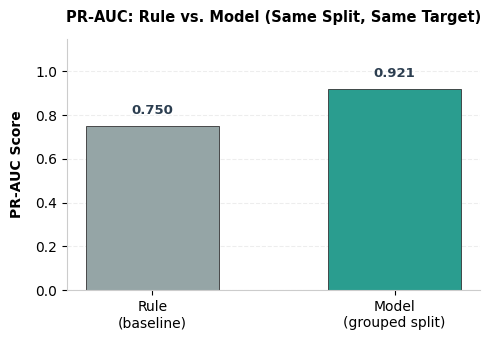

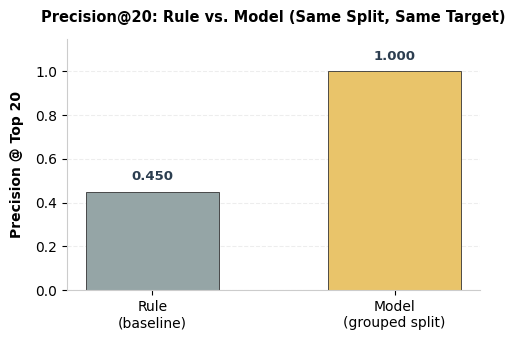

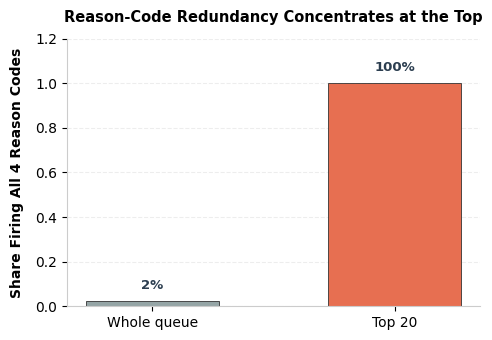

Saved 3 upgraded high-res figures to work/figures/:
  work/figures/pr_auc_comparison.png
  work/figures/precision_at_20_comparison.png
  work/figures/reason_code_redundancy.png


In [12]:
import os
import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs('work/figures', exist_ok=True)

# Global styling configuration for a clean, academic look
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Chart 1 — PR-AUC: rule vs model (grouped split)
fig, ax = plt.subplots(figsize=(5, 3.5), facecolor='white')
bars1 = ax.bar(['Rule\n(baseline)', 'Model\n(grouped split)'], [rule_pr_auc, model_pr_auc],
               color=['#95a5a6', '#2a9d8f'], width=0.55, edgecolor='#333333', linewidth=0.6)

ax.set_ylim(0, 1.15)  # Leave headroom for text
ax.set_ylabel('PR-AUC Score', fontsize=10, fontweight='600', labelpad=8)
ax.set_title('PR-AUC: Rule vs. Model (Same Split, Same Target)', fontsize=10.5, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#dddddd')
ax.set_axisbelow(True)

for bar, v in zip(bars1, [rule_pr_auc, model_pr_auc]):
    ax.text(bar.get_x() + bar.get_width()/2.0, v + 0.04, f"{v:.3f}",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('work/figures/pr_auc_comparison.png', dpi=300)
plt.show()

# Chart 2 — precision@20: rule vs model
fig, ax = plt.subplots(figsize=(5, 3.5), facecolor='white')
bars2 = ax.bar(['Rule\n(baseline)', 'Model\n(grouped split)'], [rule_p20, model_p20],
               color=['#95a5a6', '#e9c46a'], width=0.55, edgecolor='#333333', linewidth=0.6)

ax.set_ylim(0, 1.15)
ax.set_ylabel('Precision @ Top 20', fontsize=10, fontweight='600', labelpad=8)
ax.set_title('Precision@20: Rule vs. Model (Same Split, Same Target)', fontsize=10.5, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#dddddd')
ax.set_axisbelow(True)

for bar, v in zip(bars2, [rule_p20, model_p20]):
    ax.text(bar.get_x() + bar.get_width()/2.0, v + 0.04, f"{v:.3f}",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('work/figures/precision_at_20_comparison.png', dpi=300)
plt.show()

# Chart 3 — reason-code redundancy: whole queue vs top 20
fig, ax = plt.subplots(figsize=(5, 3.5), facecolor='white')
bars3 = ax.bar(['Whole queue', 'Top 20'], [whole_queue_all_four, top20_all_four],
               color=['#95a5a6', '#e76f51'], width=0.55, edgecolor='#333333', linewidth=0.6)

ax.set_ylim(0, 1.20)
ax.set_ylabel('Share Firing All 4 Reason Codes', fontsize=10, fontweight='600', labelpad=8)
ax.set_title('Reason-Code Redundancy Concentrates at the Top', fontsize=10.5, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#dddddd')
ax.set_axisbelow(True)

for bar, v in zip(bars3, [whole_queue_all_four, top20_all_four]):
    ax.text(bar.get_x() + bar.get_width()/2.0, v + 0.04, f"{v:.0%}",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('work/figures/reason_code_redundancy.png', dpi=300)
plt.show()

print("Saved 3 upgraded high-res figures to work/figures/:")
print("  work/figures/pr_auc_comparison.png")
print("  work/figures/precision_at_20_comparison.png")
print("  work/figures/reason_code_redundancy.png")

Fresh Clone Set up

---



In [17]:
# This cell is for CODE (numbers, a query, a check).
import os

%cd /content
REPO_DIR = 'FLYRANK-MACHINE-LEARNING'

if os.path.exists(REPO_DIR):
    !rm -rf {REPO_DIR}

!git clone https://github.com/Szan-12345/FLYRANK-MACHINE-LEARNING.git
%cd /content/{REPO_DIR}

# requirements.txt currently lives nested inside FLYRANK-MACHINE-LEARNING-main/
# rather than at the true repo root — this checks both locations instead of
# requiring a GitHub restructure first.
if os.path.exists('requirements.txt'):
    req_path = 'requirements.txt'
elif os.path.exists('FLYRANK-MACHINE-LEARNING-main/requirements.txt'):
    req_path = 'FLYRANK-MACHINE-LEARNING-main/requirements.txt'
else:
    req_path = None

if req_path:
    print(f"Found requirements.txt at: {req_path}")
    !pip install -r {req_path}
else:
    print("requirements.txt not found in either the root or the nested folder.")

/content
Cloning into 'FLYRANK-MACHINE-LEARNING'...
remote: Enumerating objects: 259, done.
remote: Counting objects: 100% (259/259), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 259 (delta 120), reused 127 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (259/259), 1.95 MiB | 10.47 MiB/s, done.
Resolving deltas: 100% (120/120), done.
/content/FLYRANK-MACHINE-LEARNING
Found requirements.txt at: FLYRANK-MACHINE-LEARNING-main/requirements.txt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.1 MB/s eta 0:00:00



### Dependencies & Environment
* **Self-Installing Notebooks:** Each notebook self-installs its two extra dependencies at the top of the first cell (`%pip -q install duckdb huggingface_hub`), allowing them to run standalone even outside the repository's native environment.
* **Credentials:** Notebooks connect to the warehouse via a Hugging Face read token. Set it once either as an environment variable (`HF_TOKEN`) or a Colab Secret named `HF_TOKEN` (the notebooks check both before falling back to an interactive prompt). No token is stored in any committed file.
* **Environment Versioning:** Package versions are tracked via the `requirements.txt` file at the repository root. A `pip freeze` diff against that file serves as the fastest way to check for environment mismatches if a re-run yields variant numbers.

---

### Run Order
While each notebook is fully self-contained and does not require a prior notebook to remain open in the same session, the technical pipeline logically builds in this sequence:
1. `work/notebooks/w01_research_question.ipynb`
2. `work/notebooks/w02_ml_task_framing.ipynb`
3. `work/notebooks/w03_data_contract.ipynb`
4. `work/notebooks/w04_baseline_score.ipynb`
5. `work/notebooks/w05_model.ipynb`
6. `work/notebooks/w06_validation_audit.ipynb`
7. `work/notebooks/w07_action_playbook.ipynb`
8. `work/notebooks/capstone.ipynb`

*Execution Note:* Each notebook opens directly in Colab via the badge at the top of the file, or runs locally via `jupyter nbconvert --to notebook --execute <name>.ipynb`.

---

### Random Seed & Determinism
* **Fixed Seed:** `SEED = 42` is fixed once and reused across all stochastic operations—including `train_test_split` (Week 3's honest/leaky comparison), `GroupShuffleSplit` (Week 5 and Week 6's client-grouped splits), and `permutation_importance`'s repeat sampling (Week 5). Re-runs with the same seed yield identical splits and metrics.

---

### Committed Receipts & Artifact Traceability
All numerical claims in this paper trace directly back to committed output artifacts rather than manual logging:

| File | Produced By | Contents |
| :--- | :--- | :--- |
| `work/outputs/w03_contract_metrics.json` | `w03` | Honest AUC, leaky AUC, row count, declining rate |
| `work/outputs/baseline_action_score.csv` | `w04` | The full 78,630-row baseline review queue |
| `work/outputs/w05_model_metrics.json` | `w05` | PR-AUC, precision@20, coefficients, permutation importances |
| `work/outputs/w07_action_playbook_queue.csv` | `w07` | The final blended queue (rule + model score + reason codes) |
| `work/outputs/w07_monitoring_snapshot.json` | `w07` | Base rate, scored/flagged counts, eligible-client count at run time |
| `work/outputs/w07_playbook_summary.json` | `w07` | Recommendation logic's summary statistics |

---

### Holdout & Sealed Evaluation Status
No sealed or blind evaluation is claimed in this paper, so the extra commit requirements associated with such a claim do not apply.

Specifically, `fact_content_daily_performance_sample` (the separately sealed June 2026 slice) was deliberately left unqueried throughout this project. It was not used to produce any number reported in this research paper, and it remains intact as a genuine, untouched holdout for future work rather than an evaluation set spent during iteration.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
